# K-fold cross-validation — deep MLP + dropout + L2 (weight decay)

This notebook trains the **same architecture** as the “champion” style model in `yellow_taxi_fare_ann_pytorch.ipynb`:

- **Hidden layers:** `(128, 96, 64, 32)`
- **Dropout:** `0.25` on hidden layers
- **Activation:** ReLU (hidden); linear output for regression
- **Optimizer:** **AdamW** with **weight decay** (L2-style penalty)
- **LR decay:** `ReduceLROnPlateau` on validation MSE (scaled target)
- **Early stopping** on validation MSE

**K-fold CV:** For each fold, **all sklearn steps** (imputation, scaling, one-hot, `SelectKBest`, PCA, target scaler) are **fit only on that fold’s training indices**. The neural net input size `in_dim` can change slightly between folds because one-hot width follows the training fold.

**Why CV:** A single train/validation split gives one noisy estimate of error. **K-fold** averages out split luck and is a standard way to **compare** models or report stability.

**Compare:** The last section runs a **single 85/15 holdout** with the same hyperparameters so you can contrast **mean CV validation MAE** with **one-shot test MAE** (not statistically identical—different protocols—but useful pedagogically).


In [5]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 1. Load, clean, and build `X`, `y`

Same feature logic as the main taxi notebook. No train/test split yet—CV handles splits.


In [6]:
from pathlib import Path
import pandas as pd

# Path to combined dataset
DATA_PATH = Path("../dataset_nyc_parquet/yellow_tripdata_2021-01.parquet")

# Load dataset
if not DATA_PATH.exists():
    raise FileNotFoundError("Combined dataset not found. Make sure yellow_tripdata_2021-01.parquet exists.")
df = pd.read_parquet(DATA_PATH)

#reduce size for faster training
MAX_ROWS = 250_000
RANDOM_SEED = 42

if len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)

print("Shape:", df.shape)
df.head()

pickup_col = "tpep_pickup_datetime" if "tpep_pickup_datetime" in df.columns else "pickup_datetime"
dropoff_col = "tpep_dropoff_datetime" if "tpep_dropoff_datetime" in df.columns else "dropoff_datetime"

df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")
df = df.dropna(subset=[pickup_col, dropoff_col, "fare_amount", "trip_distance"])
df = df[df[dropoff_col] > df[pickup_col]]
df["trip_duration_sec"] = (df[dropoff_col] - df[pickup_col]).dt.total_seconds()
df = df[
    (df["fare_amount"] > 0)
    & (df["fare_amount"] < 500)
    & (df["trip_distance"] > 0)
    & (df["trip_distance"] < 100)
    & (df["trip_duration_sec"] > 60)
    & (df["trip_duration_sec"] < 4 * 3600)
].copy()
if "passenger_count" in df.columns:
    df["passenger_count"] = df["passenger_count"].clip(lower=1, upper=6)

LEAKAGE_COLS = {
    "tip_amount", "tolls_amount", "extra", "mta_tax", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "airport_fee", "cbd_congestion_fee", "Airport_fee",
}

df["pickup_hour"] = df[pickup_col].dt.hour
df["pickup_dow"] = df[pickup_col].dt.dayofweek
df["pickup_month"] = df[pickup_col].dt.month

numeric_features = [
    "trip_distance", "trip_duration_sec", "pickup_hour", "pickup_dow", "pickup_month",
]
if "passenger_count" in df.columns:
    numeric_features.insert(1, "passenger_count")

cat_features = []
for c in ("RatecodeID", "payment_type", "VendorID"):
    if c in df.columns:
        cat_features.append(c)
for c in cat_features:
    df[c] = df[c].astype(str)

y = df["fare_amount"].astype(np.float32).values
X = df[numeric_features + cat_features].copy()
for c in LEAKAGE_COLS:
    if c in X.columns:
        X = X.drop(columns=[c])

print("Samples:", len(X), "features (raw columns):", X.shape[1])
X.head()


Shape: (250000, 19)
Samples: 242626 features (raw columns): 9


,trip_distance,passenger_count,trip_duration_sec,pickup_hour,pickup_dow,pickup_month,RatecodeID,payment_type,VendorID
0,1.54,3.0,480.0,16,4,1,1.0,2,2
1,1.60,1.0,548.0,18,1,1,1.0,1,2
2,9.06,NaN,1740.0,7,0,1,NaN,0,2
3,0.50,1.0,148.0,19,5,1,1.0,1,1
5,2.20,1.0,713.0,9,2,1,1.0,2,1


## 2. CV and model hyperparameters

- **`N_SPLITS`:** number of folds (default 5).  
- **`WEIGHT_DECAY`:** L2 penalty strength in AdamW.  
- **`HIDDEN` / `DROPOUT_P`:** deep + dropout architecture.


In [7]:
N_SPLITS = 5
USE_PCA = True
K_BEST = 40
PCA_VAR = 0.95
BATCH_SIZE = 2048

HIDDEN = (128, 96, 64, 32)
DROPOUT_P = 0.25
ACT_NAME = "relu"
WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 100
PATIENCE = 12

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
print("KFold:", N_SPLITS, "splits")


KFold: 5 splits


## 3. Model and training helpers


In [8]:
def make_activation(name: str) -> nn.Module:
    n = name.lower()
    if n == "relu":
        return nn.ReLU(inplace=True)
    if n == "tanh":
        return nn.Tanh()
    if n == "leaky_relu":
        return nn.LeakyReLU(0.01, inplace=True)
    if n == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)


class FareMLP(nn.Module):
    def __init__(
        self,
        in_features: int,
        hidden: tuple[int, ...],
        act_name: str = "relu",
        dropout_p: float = 0.0,
    ):
        super().__init__()
        layers: list[nn.Module] = []
        prev = in_features
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(make_activation(act_name))
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def make_loader(x: np.ndarray, y_arr: np.ndarray, shuffle: bool) -> DataLoader:
    ds = TensorDataset(
        torch.tensor(x, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.float32).unsqueeze(1),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    train: bool,
) -> float:
    if train:
        model.train()
    else:
        model.eval()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train:
            assert optimizer is not None
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            loss = criterion(model(xb), yb)
        if train:
            loss.backward()
            optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)
    return total / max(n, 1)


@torch.no_grad()
def metrics_dollars(
    model: nn.Module, loader: DataLoader, scaler_y: StandardScaler
) -> tuple[float, float, float]:
    model.eval()
    preds, actuals = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pz = model(xb).cpu().numpy()
        preds.append(pz)
        actuals.append(yb.numpy())
    pz = np.vstack(preds).ravel()
    az = np.vstack(actuals).ravel()
    pred = scaler_y.inverse_transform(pz.reshape(-1, 1)).ravel()
    act = scaler_y.inverse_transform(az.reshape(-1, 1)).ravel()
    return (
        mean_absolute_error(act, pred),
        root_mean_squared_error(act, pred),
        r2_score(act, pred),
    )


def train_one_fold(
    in_dim: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    scaler_y: StandardScaler,
    *,
    seed: int,
    verbose: bool = False,
    return_model: bool = False,
) -> dict:
    torch.manual_seed(seed)
    model = FareMLP(in_dim, HIDDEN, act_name=ACT_NAME, dropout_p=DROPOUT_P).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4, min_lr=1e-6
    )

    best_val, best_state = float("inf"), None
    stale = 0
    epochs_ran = 0

    for epoch in range(1, EPOCHS + 1):
        epochs_ran = epoch
        tr = run_epoch(model, train_loader, criterion, optimizer, train=True)
        va = run_epoch(model, val_loader, criterion, None, train=False)
        scheduler.step(va)
        if va < best_val - 1e-8:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if verbose and (epoch == 1 or epoch % 15 == 0):
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  epoch {epoch:03d} train_mse={tr:.5f} val_mse={va:.5f} lr={lr_now:.2e}")
        if stale >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    mae, rmse, r2 = metrics_dollars(model, val_loader, scaler_y)
    out = {
        "best_val_mse_scaled": best_val,
        "val_mae": mae,
        "val_rmse": rmse,
        "val_r2": r2,
        "epochs_ran": epochs_ran,
        "in_dim": in_dim,
    }
    if return_model:
        out["model"] = model
    return out


## 4. K-fold loop — refit preprocessors **inside** each fold

For fold `k`, training indices fit `ColumnTransformer` → `SelectKBest` → optional `PCA` → `StandardScaler` on `y`. Validation metrics are **out-of-fold** dollars.


In [9]:
cv_results: list[dict] = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"--- Fold {fold_idx + 1}/{N_SPLITS} ---")
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]

    preprocess = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False,
                                max_categories=30,
                            ),
                        ),
                    ]
                ),
                cat_features,
            ),
        ],
        remainder="drop",
    )
    X_tr_m = preprocess.fit_transform(X_tr)
    X_va_m = preprocess.transform(X_va)

    selector = SelectKBest(score_func=f_regression, k=min(K_BEST, X_tr_m.shape[1]))
    X_tr_s = selector.fit_transform(X_tr_m, y_tr)
    X_va_s = selector.transform(X_va_m)

    if USE_PCA:
        pca = PCA(n_components=PCA_VAR, svd_solver="full")
        X_tr_s = pca.fit_transform(X_tr_s)
        X_va_s = pca.transform(X_va_s)

    scaler_y = StandardScaler()
    y_tr_z = scaler_y.fit_transform(y_tr.reshape(-1, 1)).ravel().astype(np.float32)
    y_va_z = scaler_y.transform(y_va.reshape(-1, 1)).ravel().astype(np.float32)

    train_loader = make_loader(X_tr_s, y_tr_z, shuffle=True)
    val_loader = make_loader(X_va_s, y_va_z, shuffle=False)
    in_dim = X_tr_s.shape[1]
    print(f"  in_dim={in_dim}, train={len(y_tr)}, val={len(y_va)}")

    out = train_one_fold(
        in_dim,
        train_loader,
        val_loader,
        scaler_y,
        seed=RANDOM_SEED + 100 * (fold_idx + 1),
        verbose=True,
    )
    out["fold"] = fold_idx + 1
    cv_results.append(out)
    print(
        f"  OOF val  MAE=${out['val_mae']:.3f}  RMSE=${out['val_rmse']:.3f}  R2={out['val_r2']:.4f}"
    )

cv_df = pd.DataFrame(cv_results)
cv_df


--- Fold 1/5 ---
  in_dim=7, train=194100, val=48526
  epoch 001 train_mse=0.23181 val_mse=0.11674 lr=1.00e-03
  epoch 015 train_mse=0.09652 val_mse=0.07069 lr=1.00e-03
  epoch 030 train_mse=0.09138 val_mse=0.07056 lr=1.00e-03
  epoch 045 train_mse=0.09086 val_mse=0.06925 lr=2.50e-04
  OOF val  MAE=$0.793  RMSE=$2.739  R2=0.9352
--- Fold 2/5 ---
  in_dim=7, train=194101, val=48525
  epoch 001 train_mse=0.25146 val_mse=0.12042 lr=1.00e-03
  epoch 015 train_mse=0.12458 val_mse=0.08178 lr=1.00e-03
  epoch 030 train_mse=0.11695 val_mse=0.08439 lr=5.00e-04
  epoch 045 train_mse=0.11462 val_mse=0.08767 lr=1.25e-04
  OOF val  MAE=$0.970  RMSE=$2.848  R2=0.9290
--- Fold 3/5 ---
  in_dim=7, train=194101, val=48525
  epoch 001 train_mse=0.24951 val_mse=0.14552 lr=1.00e-03
  epoch 015 train_mse=0.11836 val_mse=0.09909 lr=1.00e-03
  epoch 030 train_mse=0.11318 val_mse=0.09351 lr=5.00e-04
  epoch 045 train_mse=0.11155 val_mse=0.08836 lr=1.25e-04
  OOF val  MAE=$1.006  RMSE=$3.007  R2=0.9196
--- Fol

,best_val_mse_scaled,val_mae,val_rmse,val_r2,epochs_ran,in_dim,fold
0,0.067658,0.792817,2.739488,0.935184,50,7,1
1,0.072859,0.969904,2.847951,0.928978,50,7,2
2,0.080895,1.006395,3.006715,0.919626,50,7,3
3,0.068968,0.939701,2.798107,0.925713,63,7,4
4,0.079338,0.992646,2.980515,0.920407,40,7,5


## 5. CV summary: mean ± std (out-of-fold validation)


    metric     mean      std
 val_MAE_$ 0.940292 0.086222
val_RMSE_$ 2.874555 0.115639
    val_R2 0.925981 0.006427

CV val MAE: $0.940 ± $0.086


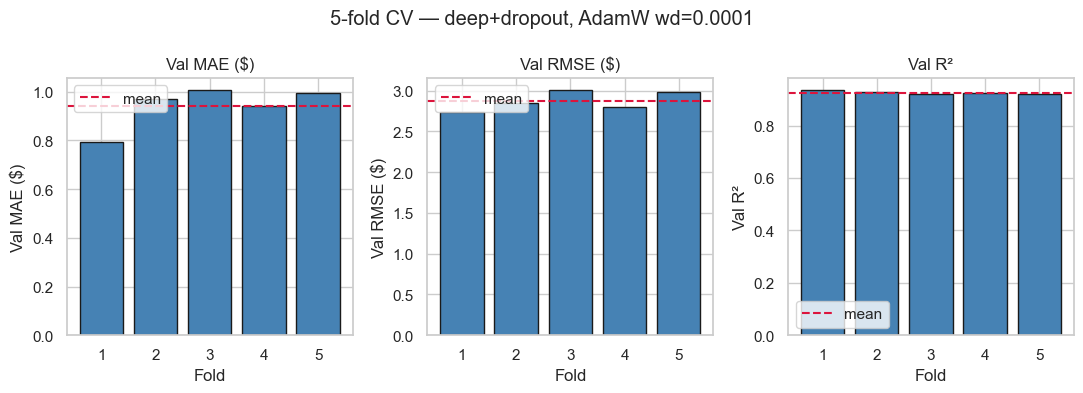

In [10]:
summary = pd.DataFrame(
    {
        "metric": ["val_MAE_$", "val_RMSE_$", "val_R2"],
        "mean": [
            cv_df["val_mae"].mean(),
            cv_df["val_rmse"].mean(),
            cv_df["val_r2"].mean(),
        ],
        "std": [
            cv_df["val_mae"].std(ddof=1),
            cv_df["val_rmse"].std(ddof=1),
            cv_df["val_r2"].std(ddof=1),
        ],
    }
)
print(summary.to_string(index=False))
print(
    f"\nCV val MAE: ${cv_df['val_mae'].mean():.3f} ± ${cv_df['val_mae'].std(ddof=1):.3f}"
)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["val_mae", "val_rmse", "val_r2"],
    ["Val MAE ($)", "Val RMSE ($)", "Val R²"],
):
    ax.bar(cv_df["fold"].astype(str), cv_df[col], color="steelblue", edgecolor="k")
    ax.axhline(cv_df[col].mean(), color="crimson", ls="--", label="mean")
    ax.set_xlabel("Fold")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
plt.suptitle(f"{N_SPLITS}-fold CV — deep+dropout, AdamW wd={WEIGHT_DECAY}")
plt.tight_layout()
plt.show()


## 6. Comparison: same model, **single** holdout (85% train / 15% test)

This does **not** use CV on the test set—the test rows are never used during training. Compare **mean CV val MAE** (each val fold is ~1/K of data) to this **test MAE** only informally: absolute numbers differ because CV averages K validation slices while the holdout uses one fixed 15% slice.


  epoch 001 train_mse=0.25639 val_mse=0.12433 lr=1.00e-03
  epoch 015 train_mse=0.12312 val_mse=0.13833 lr=5.00e-04
  epoch 030 train_mse=0.11758 val_mse=0.10441 lr=2.50e-04
  epoch 045 train_mse=0.11517 val_mse=0.10852 lr=6.25e-05
  epoch 060 train_mse=0.11366 val_mse=0.10245 lr=7.81e-06

Holdout internal val MAE: $1.015
Holdout **test** MAE: $1.013  RMSE: $3.044  R2: 0.9199

                 protocol    MAE_$   RMSE_$       R2
5-fold CV (mean OOF val) 0.940292 2.874555 0.925981
Single split (test, 15%) 1.013477 3.044464 0.919867


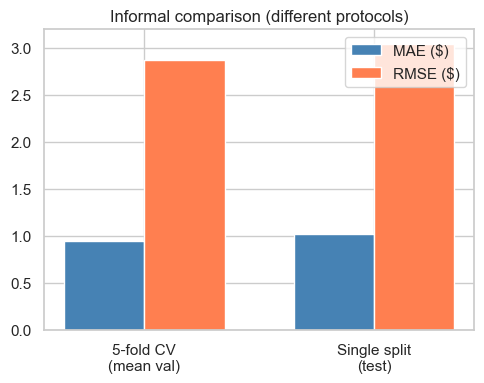

In [11]:
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_SEED
)
X_tr_inner, X_val_h, y_tr_inner, y_val_h = train_test_split(
    X_tr_h, y_tr_h, test_size=0.15 / 0.85, random_state=RANDOM_SEED
)

preprocess_h = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                            max_categories=30,
                        ),
                    ),
                ]
            ),
            cat_features,
        ),
    ],
    remainder="drop",
)
X_tr_m = preprocess_h.fit_transform(X_tr_inner)
X_va_m = preprocess_h.transform(X_val_h)
X_te_m = preprocess_h.transform(X_te_h)

selector_h = SelectKBest(score_func=f_regression, k=min(K_BEST, X_tr_m.shape[1]))
X_tr_s = selector_h.fit_transform(X_tr_m, y_tr_inner)
X_va_s = selector_h.transform(X_va_m)
X_te_s = selector_h.transform(X_te_m)

if USE_PCA:
    pca_h = PCA(n_components=PCA_VAR, svd_solver="full")
    X_tr_s = pca_h.fit_transform(X_tr_s)
    X_va_s = pca_h.transform(X_va_s)
    X_te_s = pca_h.transform(X_te_s)

scaler_y_h = StandardScaler()
y_tr_z = scaler_y_h.fit_transform(y_tr_inner.reshape(-1, 1)).ravel().astype(np.float32)
y_val_z = scaler_y_h.transform(y_val_h.reshape(-1, 1)).ravel().astype(np.float32)
y_te_z = scaler_y_h.transform(y_te_h.reshape(-1, 1)).ravel().astype(np.float32)

train_h = make_loader(X_tr_s, y_tr_z, shuffle=True)
val_h = make_loader(X_va_s, y_val_z, shuffle=False)
test_h = make_loader(X_te_s, y_te_z, shuffle=False)
in_dim_h = X_tr_s.shape[1]

holdout = train_one_fold(
    in_dim_h,
    train_h,
    val_h,
    scaler_y_h,
    seed=RANDOM_SEED + 999,
    verbose=True,
    return_model=True,
)
model_h = holdout["model"]
test_mae, test_rmse, test_r2 = metrics_dollars(model_h, test_h, scaler_y_h)
print(f"\nHoldout internal val MAE: ${holdout['val_mae']:.3f}")
print(f"Holdout **test** MAE: ${test_mae:.3f}  RMSE: ${test_rmse:.3f}  R2: {test_r2:.4f}")

cmp = pd.DataFrame(
    [
        {
            "protocol": f"{N_SPLITS}-fold CV (mean OOF val)",
            "MAE_$": cv_df["val_mae"].mean(),
            "RMSE_$": cv_df["val_rmse"].mean(),
            "R2": cv_df["val_r2"].mean(),
        },
        {
            "protocol": "Single split (test, 15%)",
            "MAE_$": test_mae,
            "RMSE_$": test_rmse,
            "R2": test_r2,
        },
    ]
)
print("\n", cmp.to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(2)
w = 0.35
ax.bar(x - w / 2, [cv_df["val_mae"].mean(), test_mae], w, label="MAE ($)", color="steelblue")
ax.bar(
    x + w / 2,
    [cv_df["val_rmse"].mean(), test_rmse],
    w,
    label="RMSE ($)",
    color="coral",
)
ax.set_xticks(x)
ax.set_xticklabels([f"{N_SPLITS}-fold CV\n(mean val)", "Single split\n(test)"])
ax.legend()
ax.set_title("Informal comparison (different protocols)")
plt.tight_layout()
plt.show()


## 7. Test set — predicted vs actual (holdout model)

The **holdout** `model_h` is evaluated on the **15% test split** (`X_te_h`, `y_te_h`); those rows were not used for training or early stopping.

Below: **largest absolute errors** (often unusual trips), a **random sample** for typical cases, error **summary statistics**, and **plots** (actual vs predicted and residual histogram).

In [12]:
from IPython.display import display

model_h.eval()
test_pred_chunks: list[np.ndarray] = []
with torch.no_grad():
    for xb, _ in test_h:
        xb = xb.to(DEVICE)
        test_pred_chunks.append(model_h(xb).cpu().numpy())
test_pred_z = np.vstack(test_pred_chunks).ravel()
y_test_pred = scaler_y_h.inverse_transform(test_pred_z.reshape(-1, 1)).ravel()
y_test_actual = y_te_h.astype(float)

comparison_df = pd.DataFrame(
    {
        "trip_mi": X_te_h["trip_distance"].values,
        "dur_min": np.round(X_te_h["trip_duration_sec"].values / 60, 1),
        "hour": X_te_h["pickup_hour"].values,
        "actual_fare_$": np.round(y_test_actual, 2),
        "predicted_fare_$": np.round(y_test_pred, 2),
        "error_$": np.round(y_test_pred - y_test_actual, 2),
        "abs_error_$": np.round(np.abs(y_test_pred - y_test_actual), 2),
    }
)

print(
    f"Test set size: {len(comparison_df)} | MAE=${test_mae:.3f} | RMSE=${test_rmse:.3f} | R²={test_r2:.4f}\n"
)

print("--- Largest absolute errors (top 25) ---")
worst = comparison_df.sort_values("abs_error_$", ascending=False).head(25).reset_index(drop=True)
display(worst)

print("\n--- Random sample of 20 rows ---")
rng = np.random.default_rng(RANDOM_SEED + 7)
sample_idx = rng.choice(len(comparison_df), size=min(20, len(comparison_df)), replace=False)
sample_tbl = comparison_df.iloc[sample_idx].sort_values("actual_fare_$").reset_index(drop=True)
display(sample_tbl)

print("\n--- Error summary (all test rows) ---")
display(comparison_df[["error_$", "abs_error_$"]].describe())

Test set size: 36394 | MAE=$1.013 | RMSE=$3.044 | R²=0.9199

--- Largest absolute errors (top 25) ---


,trip_mi,dur_min,hour,actual_fare_$,predicted_fare_$,error_$,abs_error_$
0,46.82,57.9,16,220.00,106.760002,-113.24,113.24
1,1.83,239.5,11,15.20,117.519997,102.32,102.32
2,30.33,64.5,6,187.00,85.830002,-101.17,101.17
3,38.64,43.0,22,180.50,85.449997,-95.05,95.05
4,0.02,31.7,13,100.00,17.870001,-82.13,82.13
5,34.16,73.3,14,166.00,93.570000,-72.43,72.43
6,19.53,48.5,14,118.00,50.150002,-67.85,67.85
7,12.60,22.5,11,100.00,32.799999,-67.20,67.20
8,10.26,145.0,20,31.00,96.680000,65.68,65.68
9,25.60,47.1,19,130.00,64.820000,-65.18,65.18



--- Random sample of 20 rows ---


,trip_mi,dur_min,hour,actual_fare_$,predicted_fare_$,error_$,abs_error_$
0,0.50,2.4,12,4.00,4.550000,0.55,0.55
1,0.50,3.3,17,4.50,4.860000,0.36,0.36
2,0.72,4.6,12,5.00,5.420000,0.42,0.42
3,0.69,4.4,8,5.00,5.250000,0.25,0.25
4,0.90,5.9,17,6.00,5.870000,-0.13,0.13
5,1.61,4.8,18,6.50,6.300000,-0.20,0.20
6,1.86,8.2,14,8.00,8.340000,0.34,0.34
7,1.97,9.7,12,9.00,8.810000,-0.19,0.19
8,2.20,9.7,12,9.00,9.360000,0.36,0.36
9,1.84,10.3,14,9.50,8.840000,-0.66,0.66



--- Error summary (all test rows) ---


,error_$,abs_error_$
count,36394.000000,36394.000000
mean,-0.135666,1.013476
std,3.041498,2.870880
min,-113.240000,0.000000
25%,-0.270000,0.150000
50%,0.060000,0.340000
75%,0.400000,0.720000
max,102.320000,113.240000


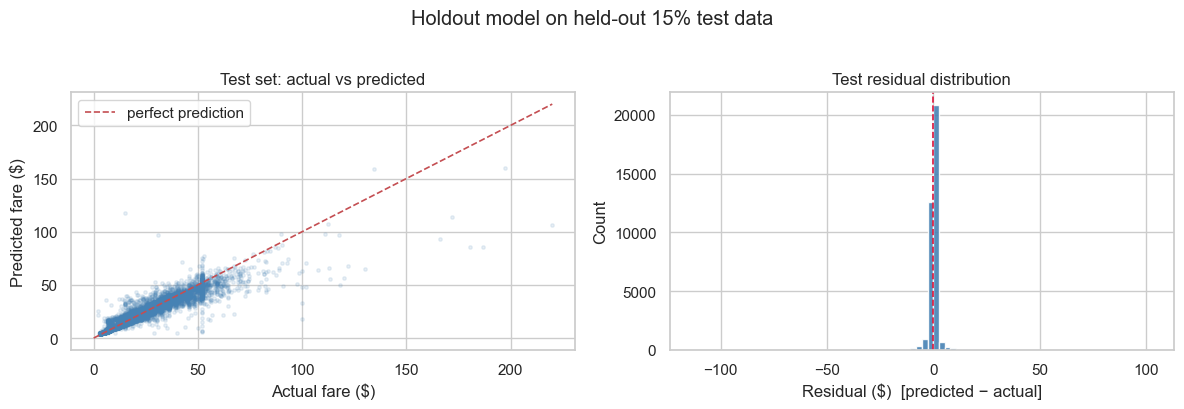

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(y_test_actual, y_test_pred, alpha=0.12, s=6, c="steelblue")
mx = max(float(np.max(y_test_actual)), float(np.max(y_test_pred)))
ax.plot([0, mx], [0, mx], "r--", lw=1.2, label="perfect prediction")
ax.set_xlabel("Actual fare ($)")
ax.set_ylabel("Predicted fare ($)")
ax.set_title("Test set: actual vs predicted")
ax.legend(loc="upper left")

ax = axes[1]
residuals = y_test_pred - y_test_actual
ax.hist(residuals, bins=80, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(0, color="crimson", ls="--", lw=1.2)
ax.set_xlabel("Residual ($)  [predicted − actual]")
ax.set_ylabel("Count")
ax.set_title("Test residual distribution")

plt.suptitle("Holdout model on held-out 15% test data", y=1.02)
plt.tight_layout()
plt.show()

### Note

- **Section 6** trains `model_h` with `train_one_fold(..., return_model=True)` (one run; same weights for validation metrics inside that function and for **§7** test tables/plots).
- **K-fold metrics** in §§4–5 are **out-of-fold validation** only; they are not the same rows as the 15% test split in §7.
